# Calibration Grid Cache

This notebook defines the calibration grid, runs the batch, and saves one compressed `JLD2` file per parameterization in `result/calibration_grid/`.

In [1]:
using LinearAlgebra, Statistics
include("src/structs_s.jl")
include("src/utils_s.jl")
include("src/solver_s.jl")
include("src/simulation_s.jl")
include("src/calibration_grid_s.jl")
Threads.nthreads()

8

In [2]:
# Define the calibration grid here, not in the helper file.
phi_bad_vals = collect(0.80:0.01:0.99)
phi_good_vals = collect(0.80:0.01:0.99)
beta_vals = collect(range(0.50, 0.95, length = 5))
ps_bad_vals = [0.01, 0.25]

total_cases = length(phi_bad_vals) * length(phi_good_vals) * length(beta_vals) * length(ps_bad_vals)
(; phi_bad_vals, phi_good_vals, beta_vals, ps_bad_vals, total_cases)

(phi_bad_vals = [0.94, 0.9426315789473684, 0.9452631578947368, 0.9478947368421052, 0.9505263157894737, 0.9531578947368421, 0.9557894736842105, 0.958421052631579, 0.9610526315789474, 0.9636842105263158, 0.9663157894736842, 0.9689473684210527, 0.9715789473684211, 0.9742105263157895, 0.9768421052631578, 0.9794736842105263, 0.9821052631578947, 0.9847368421052631, 0.9873684210526316, 0.99], phi_good_vals = [0.94, 0.9426315789473684, 0.9452631578947368, 0.9478947368421052, 0.9505263157894737, 0.9531578947368421, 0.9557894736842105, 0.958421052631579, 0.9610526315789474, 0.9636842105263158, 0.9663157894736842, 0.9689473684210527, 0.9715789473684211, 0.9742105263157895, 0.9768421052631578, 0.9794736842105263, 0.9821052631578947, 0.9847368421052631, 0.9873684210526316, 0.99], beta_vals = [0.5, 0.6125, 0.725, 0.8375, 0.95], ps_bad_vals = [0.01, 0.25], total_cases = 4000)

In [3]:
base_raw = Model(
    Nb = 3000,
    Ne = 17,
    max_iter = 100,
    max_iter_vd = 200,
    max_iter_x = 2000,
    pub = 0.65,
)

results_dir = joinpath(pwd(), "result", "calibration_grid")
# results = run_calibration_grid(
#     base_raw,
#     phi_bad_vals,
#     phi_good_vals,
#     beta_vals,
#     ps_bad_vals,
#     results_dir,
# )

results

LoadError: UndefVarError: `results` not defined

## check results of one run

status = solved
converged = true


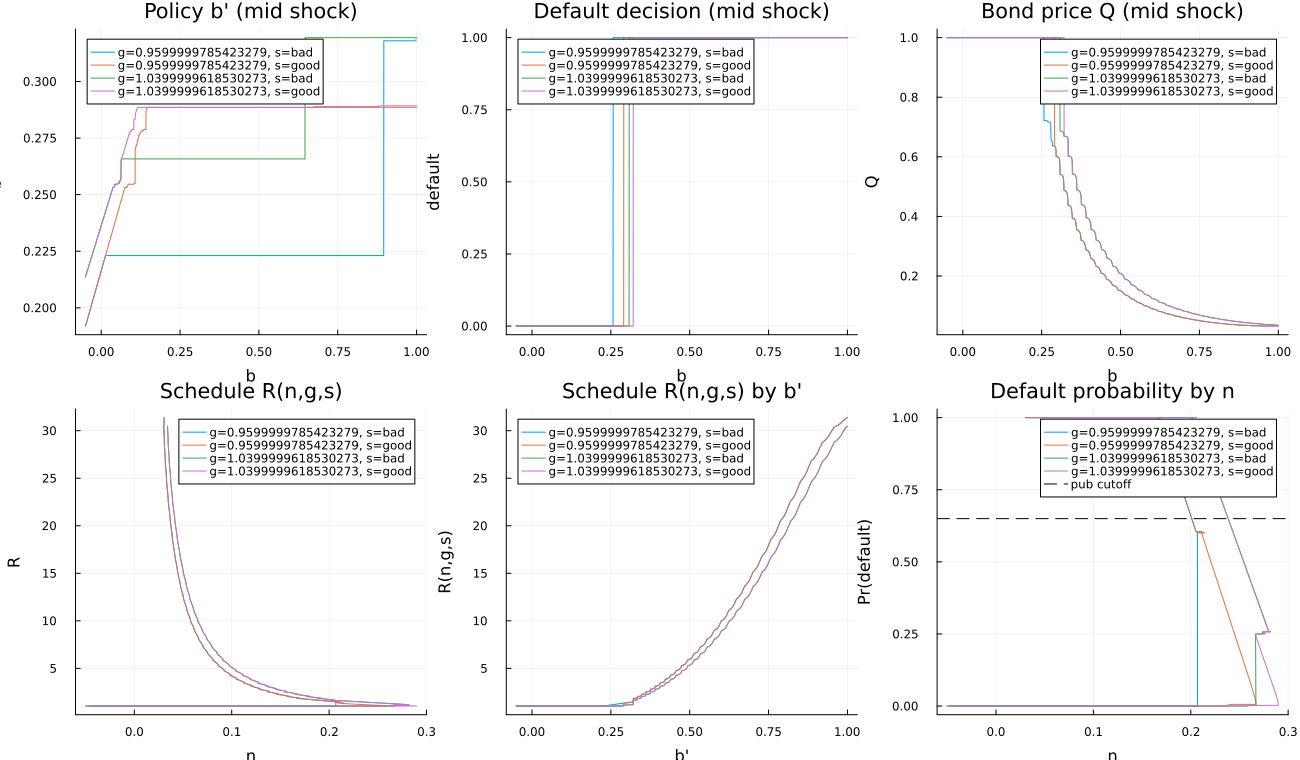

In [4]:
using Plots, Statistics

# Grid definition:
# phi_bad_vals:  0.80 to 0.99 by 0.01, 20 points
# phi_good_vals: 0.80 to 0.99 by 0.01, 20 points
# beta_vals:     0.50 to 0.95, 5 points
# ps_bad_vals:   [0.01, 0.25], 2 points
#
# Grid-position order below matches the calibration loop:
# (ps_bad index, beta index, phi_bad index, phi_good index)

i_ps_bad = 1
i_beta = 3
i_phi_bad = 1
i_phi_good = 1

ps_bad = ps_bad_vals[i_ps_bad]
beta = beta_vals[i_beta]
phi_bad = phi_bad_vals[i_phi_bad]
phi_good = phi_good_vals[i_phi_good]

case_idx = LinearIndices((
    length(ps_bad_vals),
    length(beta_vals),
    length(phi_bad_vals),
    length(phi_good_vals),
))[i_ps_bad, i_beta, i_phi_bad, i_phi_good]

case_path = joinpath(results_dir, case_filename(phi_bad, phi_good, beta, ps_bad))
case = load_case(case_path)

model = case.model
sol = case.sol

println("status = ", case.status)
println("converged = ", case.converged)

(
    case_idx = case_idx,
    path = case_path,
    params = (ps_bad = ps_bad, beta = beta, phi_bad = phi_bad, phi_good = phi_good),
    outer_iters = sol.outer_iters,
    share_default = mean(sol.d),
)

b = model.b
g = model.g
pub = model.pub
e_idx = Int(cld(model.Ne, 2))
s_labels = ["bad", "good"]

summary_table = [
    let mask = sol.schedule_mask[:, gi, si]
        (
            g_state = gi,
            s_state = si,
            mean_R = any(mask) ? mean(sol.R[mask, gi, si]) : missing,
            mean_n = any(mask) ? mean(sol.n[mask, gi, si]) : missing,
            max_pdefault = any(mask) ? maximum(sol.pdefault[mask, gi, si]) : missing,
            share_default_midshock = mean(sol.d[:, gi, si, e_idx]),
        )
    end
    for gi in 1:model.Ng, si in 1:model.Ns
]

summary_table

p1 = plot(title = "Policy b' (mid shock)", xlabel = "b", ylabel = "b'")
p2 = plot(title = "Default decision (mid shock)", xlabel = "b", ylabel = "default")
p3 = plot(title = "Bond price Q (mid shock)", xlabel = "b", ylabel = "Q")
p4 = plot(title = "Schedule R(n,g,s)", xlabel = "n", ylabel = "R")
p5 = plot(title = "Schedule R(n,g,s) by b'", xlabel = "b'", ylabel = "R(n,g,s)")
p6 = plot(title = "Default probability by n", xlabel = "n", ylabel = "Pr(default)")

for gi in 1:model.Ng
    for si in 1:model.Ns
        mask = sol.schedule_mask[:, gi, si]
        bprime_policy = b[sol.b_policy_idx[:, gi, si, e_idx]]
        label = "g=$(g[gi]), s=$(s_labels[si])"

        plot!(p1, b, bprime_policy, label = label)
        plot!(p2, b, Float64.(sol.d[:, gi, si, e_idx]), label = label)
        plot!(p3, b, sol.Q[:, gi, si, e_idx], label = label)
        if any(mask)
            plot!(p4, sol.n[mask, gi, si], sol.R[mask, gi, si], label = label)
            plot!(p5, b[mask], sol.R[mask, gi, si], label = label)
            plot!(p6, sol.n[mask, gi, si], sol.pdefault[mask, gi, si], label = label)
        end
    end
end

hline!(p6, [pub], color = :black, linestyle = :dash, label = "pub cutoff")
plot(p1, p2, p3, p4, p5, p6, layout = (2, 3), size = (1300, 760))


In [11]:
using Printf

sim = simulate(model, sol; T = 200_000, seed = 1234)
moments = summarize_simulation(sim, model; sol = sol, burnin = 10_000)

function format_num(x)
    return isnan(x) ? "" : @sprintf("%.4f", x)
end

function build_case_text_table(moments)
    rows = [
        ("avg(spread)", moments.all.avg_spread, moments.low.avg_spread, moments.high.avg_spread),
        ("avg(qb/y)", moments.all.avg_qb_to_y, moments.low.avg_qb_to_y, moments.high.avg_qb_to_y),
        ("avg(f/y)", moments.all.avg_f_to_y, moments.low.avg_f_to_y, moments.high.avg_f_to_y),
        ("avg(n/y)", moments.all.avg_n_to_y, moments.low.avg_n_to_y, moments.high.avg_n_to_y),
        ("avg(b/y)", moments.all.avg_b_to_y, moments.low.avg_b_to_y, moments.high.avg_b_to_y),
        ("avg(tb/y)", moments.all.avg_tb_to_y, moments.low.avg_tb_to_y, moments.high.avg_tb_to_y),
        ("default rate", moments.all.default_rate, moments.low.default_rate, moments.high.default_rate),
    ]

    io = IOBuffer()
    println(io, rpad("Moment", 18), lpad("All", 12), lpad("Bad time", 12), lpad("Good time", 12))
    println(io, repeat("-", 54))
    for (label, vall, vbad, vgood) in rows
        println(io, rpad(label, 18), lpad(format_num(vall), 12), lpad(format_num(vbad), 12), lpad(format_num(vgood), 12))
    end
    return String(take!(io))
end

table_text = build_case_text_table(moments)
println(table_text)


Moment                     All    Bad time   Good time
------------------------------------------------------
avg(spread)             0.0014      0.0023      0.0009
avg(qb/y)               0.2784      0.2782      0.2784
avg(f/y)                0.2885      0.2886      0.2884
avg(n/y)                0.2784      0.2782      0.2784
avg(b/y)                0.2860      0.3002      0.2773
avg(tb/y)               0.0076      0.0219     -0.0012
default rate            0.0037      0.0096      0.0000



## plot dist of moments

In [24]:
using Base.Threads, Printf

# For each (phi_bad, phi_good) grid point, simulate the default rate for all beta values.
# Workload here: 20 x 20 x 5 x 2 = 4000 simulations.

ps_plot_vals = [0.01, 0.25]
sim_T_phi_grid = 20_000
sim_burnin_phi_grid = 1_000

function mean_nonan(x)
    vals = filter(v -> !isnan(v), x)
    return isempty(vals) ? NaN : mean(vals)
end

phi_default_rate_beta = Dict{Float64, Array{Float64, 3}}()
phi_default_rate_avg = Dict{Float64, Matrix{Float64}}()
phi_converged_beta = Dict{Float64, Array{Float64, 3}}()

println("Running ", length(phi_bad_vals) * length(phi_good_vals) * length(beta_vals) * length(ps_plot_vals), " simulations with ", Threads.nthreads(), " threads.")

for ps_bad in ps_plot_vals
    default_rates = fill(NaN, length(beta_vals), length(phi_bad_vals), length(phi_good_vals))
    converged_grid = fill(NaN, length(beta_vals), length(phi_bad_vals), length(phi_good_vals))
    jobs = [(beta_idx, phi_bad_idx, phi_good_idx) for beta_idx in eachindex(beta_vals), phi_bad_idx in eachindex(phi_bad_vals), phi_good_idx in eachindex(phi_good_vals)]

    Threads.@threads for job_idx in eachindex(jobs)
        beta_idx, phi_bad_idx, phi_good_idx = jobs[job_idx]
        beta = beta_vals[beta_idx]
        phi_bad = phi_bad_vals[phi_bad_idx]
        phi_good = phi_good_vals[phi_good_idx]
        case_path = joinpath(results_dir, case_filename(phi_bad, phi_good, beta, ps_bad))

        if isfile(case_path)
            case = load_case(case_path)
            converged_grid[beta_idx, phi_bad_idx, phi_good_idx] = case.converged ? 1.0 : 0.0
            if case.sol !== nothing && case.status != "error"
                b0_idx = findmin(abs.(case.model.b))[2]
                sim_seed = 100_000 * Int(round(100 * ps_bad)) + 1_000 * beta_idx + 50 * phi_bad_idx + phi_good_idx
                sim_case = simulate(case.model, case.sol; T = sim_T_phi_grid, b0_idx = b0_idx, seed = sim_seed)
                moments_case = summarize_simulation(sim_case, case.model; sol = case.sol, burnin = sim_burnin_phi_grid, nbins = 100)
                default_rates[beta_idx, phi_bad_idx, phi_good_idx] = moments_case.default_rate
            end
        end
    end

    phi_default_rate_beta[ps_bad] = default_rates
    phi_default_rate_avg[ps_bad] = [mean_nonan(default_rates[:, i, j]) for i in eachindex(phi_bad_vals), j in eachindex(phi_good_vals)]
    phi_converged_beta[ps_bad] = converged_grid
end

(
    sim_T_phi_grid = sim_T_phi_grid,
    sim_burnin_phi_grid = sim_burnin_phi_grid,
)


Running 4000 simulations with 8 threads.


(sim_T_phi_grid = 20000, sim_burnin_phi_grid = 1000, heatmap_clims = (0.0, 0.4739473684210526), diff_clims = (-0.37005263157894736, 0.37005263157894736))

In [ ]:
using Statistics

all_heatmap_vals = vcat(vec(phi_default_rate_beta[0.01]), vec(phi_default_rate_beta[0.25]))
heatmap_vals_nonan = filter(v -> !isnan(v), all_heatmap_vals)
heatmap_clims = (minimum(heatmap_vals_nonan), maximum(heatmap_vals_nonan))

all_diff_vals = vec(phi_default_rate_beta[0.25] .- phi_default_rate_beta[0.01])
diff_vals_nonan = filter(v -> !isnan(v), all_diff_vals)
diff_abs_max = maximum(abs.(diff_vals_nonan))
diff_clims = (-diff_abs_max, diff_abs_max)

(
    heatmap_clims = heatmap_clims,
    diff_clims = diff_clims,
)


Convergence


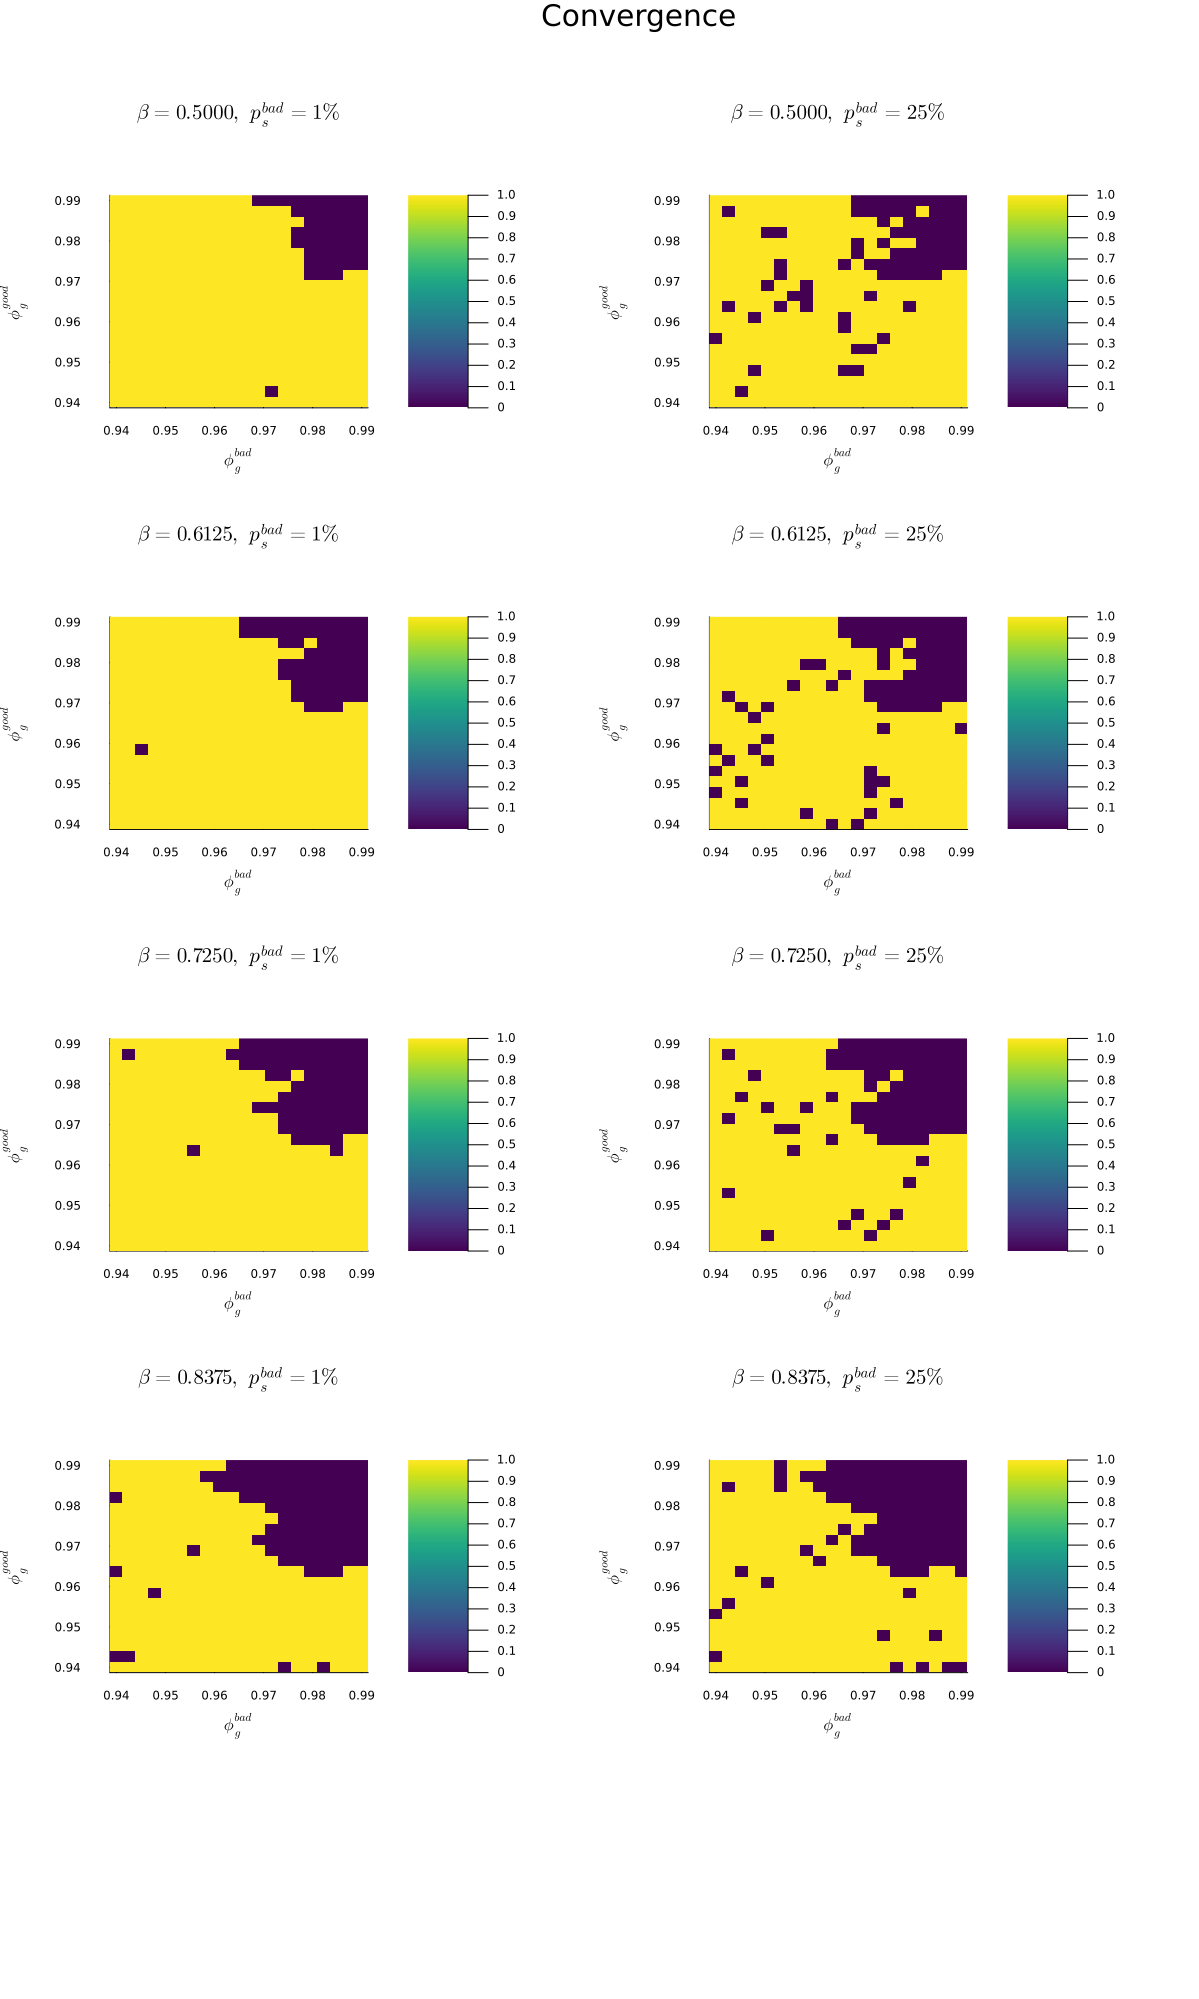

In [49]:
using Plots, LaTeXStrings, Printf

println("Convergence")
conv_panels = Any[]

for beta_idx in 1:4 #eachindex(beta_vals)
    beta = beta_vals[beta_idx]

    p1 = heatmap(
        phi_bad_vals,
        phi_good_vals,
        phi_converged_beta[0.01][beta_idx, :, :]',
        xlabel = L"\phi_g^{bad}",
        ylabel = L"\phi_g^{good}",
        title = latexstring("\\beta = ", @sprintf("%.4f", beta), ",\\ p_s^{bad}=1\\%"),
        color = :viridis,
        clims = (0, 1),
        left_margin = 10Plots.mm,
        right_margin = 6Plots.mm,
        bottom_margin = 10Plots.mm,
        top_margin = 8Plots.mm,
    )

    p2 = heatmap(
        phi_bad_vals,
        phi_good_vals,
        phi_converged_beta[0.25][beta_idx, :, :]',
        xlabel = L"\phi_g^{bad}",
        ylabel = L"\phi_g^{good}",
        title = latexstring("\\beta = ", @sprintf("%.4f", beta), ",\\ p_s^{bad}=25\\%"),
        color = :viridis,
        clims = (0, 1),
        left_margin = 10Plots.mm,
        right_margin = 6Plots.mm,
        bottom_margin = 10Plots.mm,
        top_margin = 8Plots.mm,
    )

    append!(conv_panels, [p1, p2])
end

conv_fig = plot(
    conv_panels...,
    layout = (length(beta_vals), 2),
    size = (1200, 400 * length(beta_vals)),
    plot_title = "Convergence",
    plot_titlefontsize = 20,
    top_margin = 15Plots.mm,
)
savefig(conv_fig, joinpath(results_dir, "convergence_heatmaps_by_beta.png"))
display(conv_fig)


Default rate


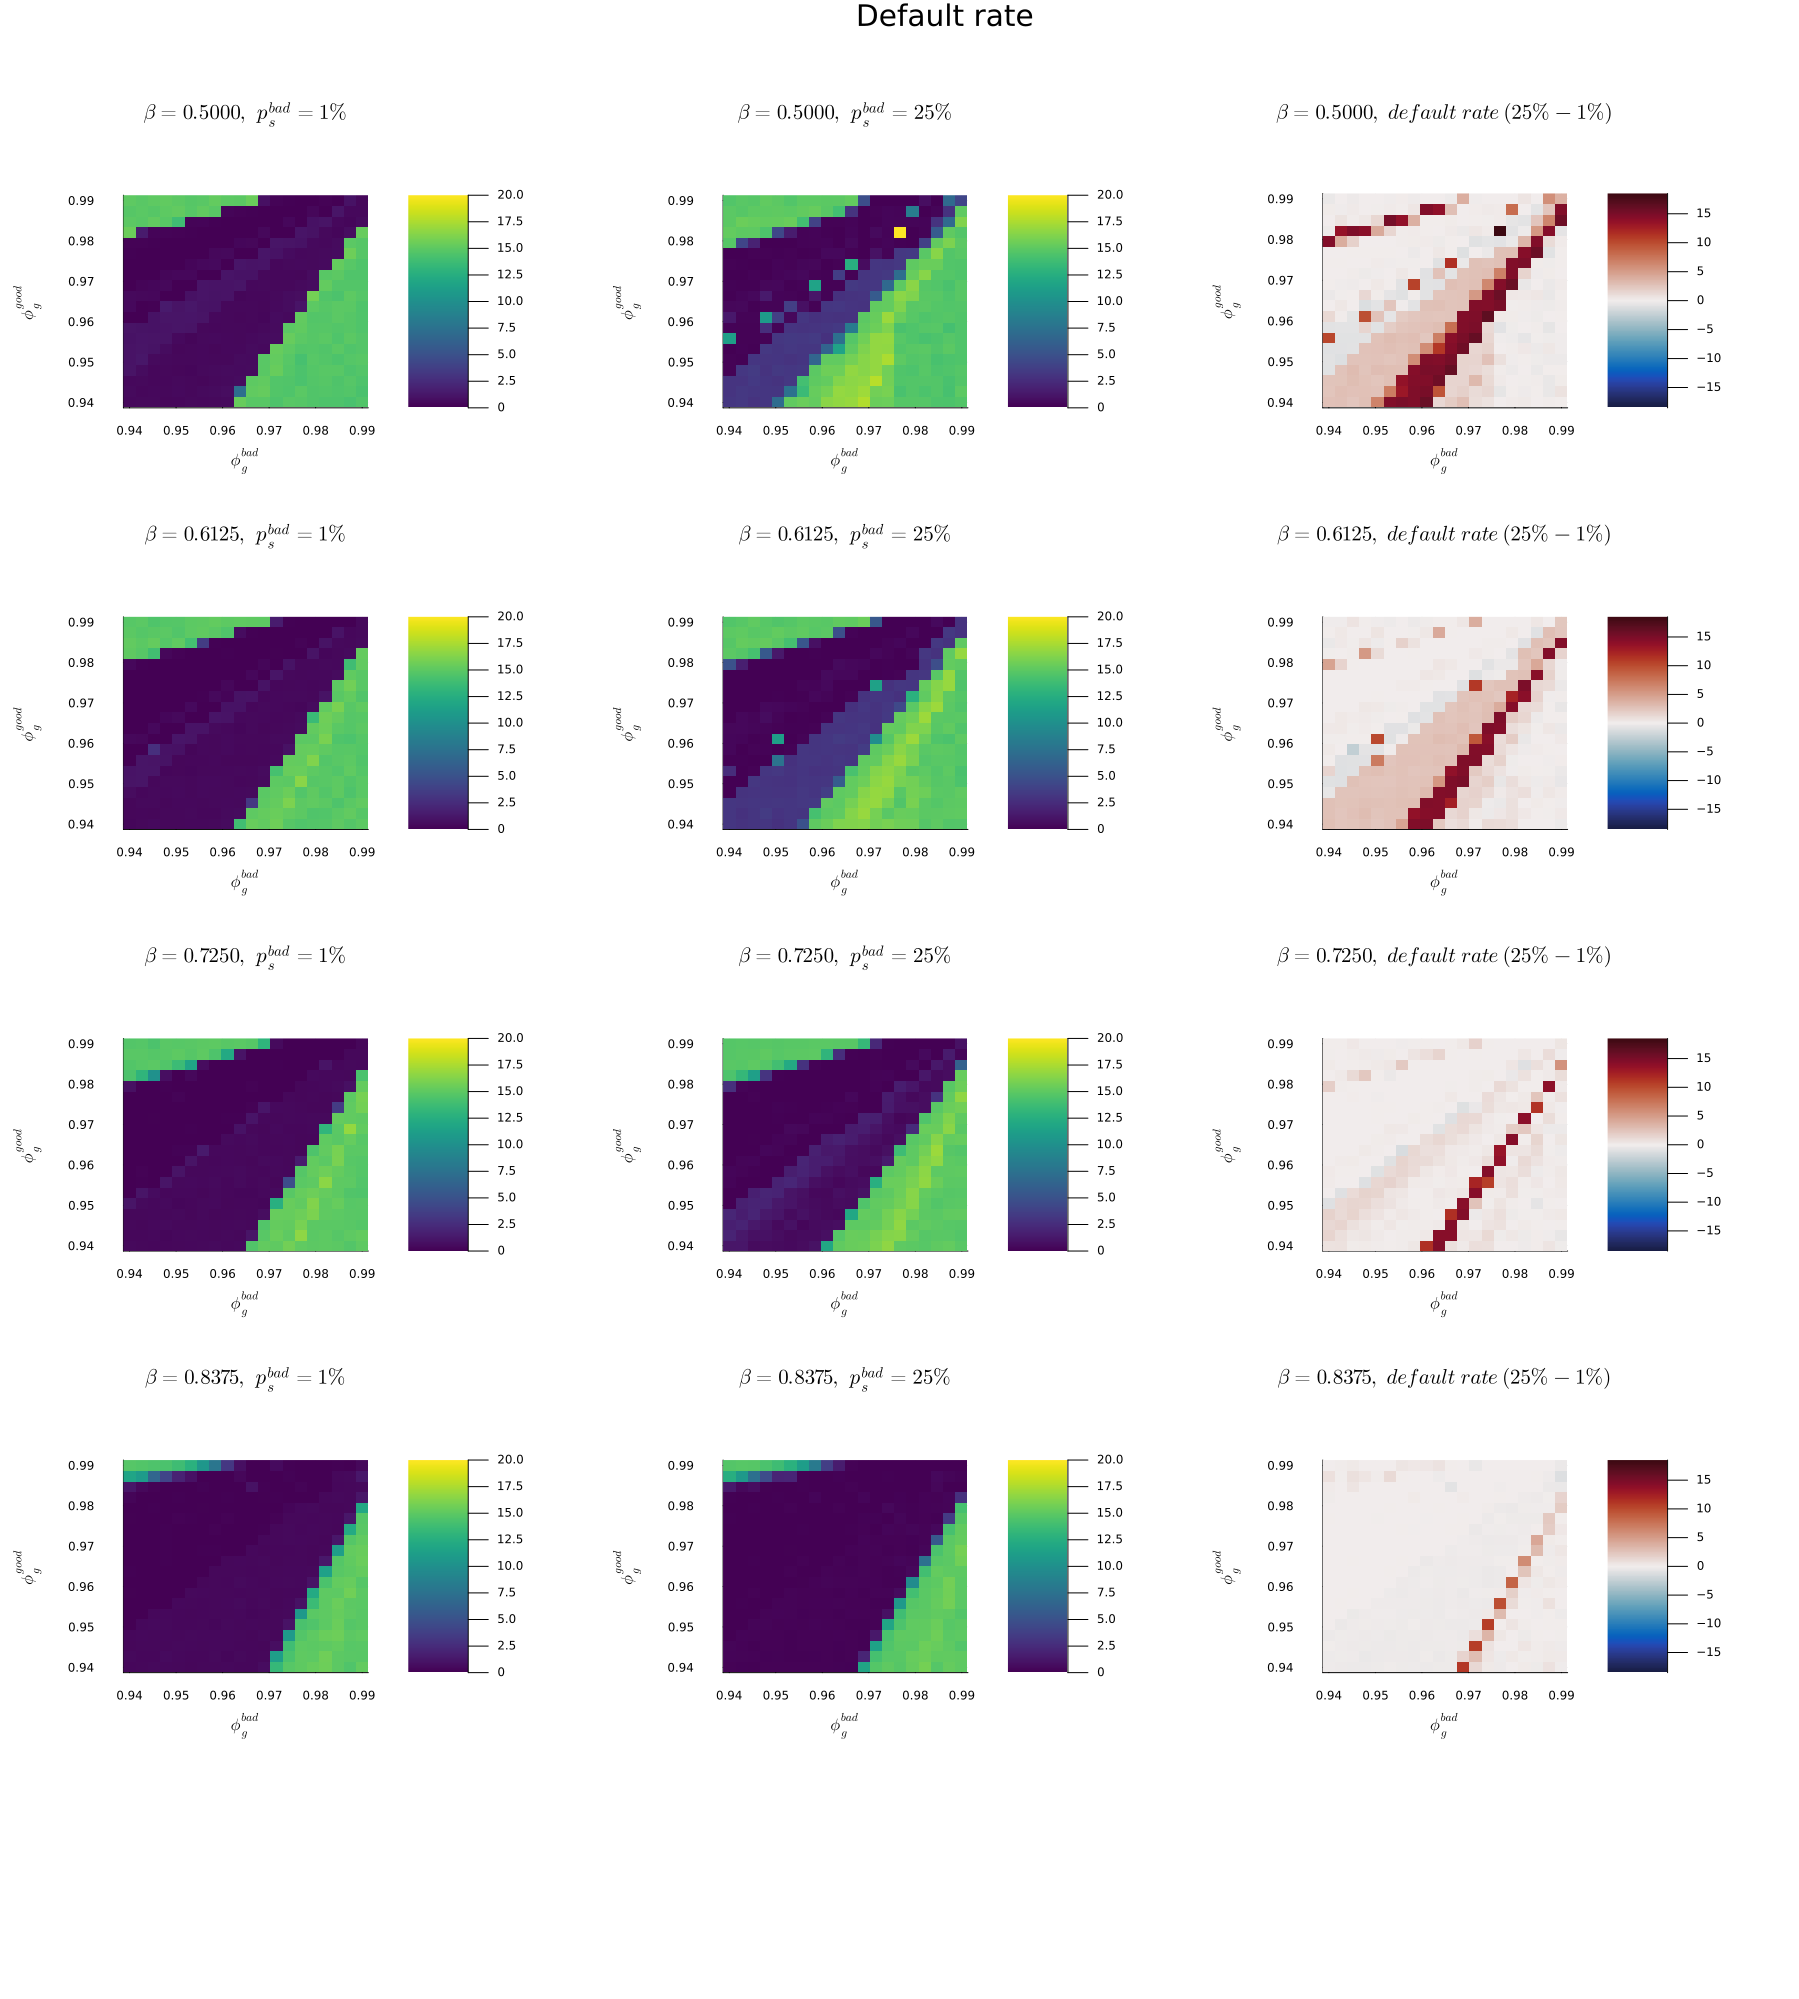

In [51]:
using Plots, LaTeXStrings, Printf

println("Default rate")
panels = Any[]

for beta_idx in 1:4 #eachindex(beta_vals)
    beta = beta_vals[beta_idx]

    p1 = heatmap(
        phi_bad_vals,
        phi_good_vals,
        100 .* phi_default_rate_beta[0.01][beta_idx, :, :]',
        xlabel = L"\phi_g^{bad}",
        ylabel = L"\phi_g^{good}",
        title = latexstring("\\beta = ", @sprintf("%.4f", beta), ",\\ p_s^{bad}=1\\%"),
        color = :viridis,
        clims = 100 .* (0,0.2), #heatmap_clims,
        left_margin = 10Plots.mm,
        right_margin = 6Plots.mm,
        bottom_margin = 10Plots.mm,
        top_margin = 8Plots.mm,
    )

    p2 = heatmap(
        phi_bad_vals,
        phi_good_vals,
        100 .* phi_default_rate_beta[0.25][beta_idx, :, :]',
        xlabel = L"\phi_g^{bad}",
        ylabel = L"\phi_g^{good}",
        title = latexstring("\\beta = ", @sprintf("%.4f", beta), ",\\ p_s^{bad}=25\\%"),
        color = :viridis,
        clims = 100 .* (0,0.2), #heatmap_clims,
        left_margin = 10Plots.mm,
        right_margin = 6Plots.mm,
        bottom_margin = 10Plots.mm,
        top_margin = 8Plots.mm,
    )

    p3 = heatmap(
        phi_bad_vals,
        phi_good_vals,
        100 .* (phi_default_rate_beta[0.25][beta_idx, :, :]' .- phi_default_rate_beta[0.01][beta_idx, :, :]'),
        xlabel = L"\phi_g^{bad}",
        ylabel = L"\phi_g^{good}",
        title = latexstring("\\beta = ", @sprintf("%.4f", beta), ",\\ default\\ rate\\ (25\\% - 1\\%)"),
        color = :balance,
        clims = 100 .* diff_clims./2,
        left_margin = 10Plots.mm,
        right_margin = 6Plots.mm,
        bottom_margin = 10Plots.mm,
        top_margin = 8Plots.mm,
    )

    append!(panels, [p1, p2, p3])
end

default_fig = plot(
    panels...,
    layout = (length(beta_vals), 3),
    size = (1800, 400 * length(beta_vals)),
    plot_title = "Default rate",
    plot_titlefontsize = 20,
    top_margin = 15Plots.mm,
)
savefig(default_fig, joinpath(results_dir, "default_rate_heatmaps_by_beta.png"))
display(default_fig)
